# The E-commerce "Mega-Store" Analyzer
The Problem: Help a store manager understand their business performance.

**Focus Area**
---
- Analyzing millions of transactions. 
- Use Pandas for complex `Group By` Operations
- Use NumPy for high-performance vectorized maths such as calculating discounts, tax, and profit margins.

In [1]:
import numpy as np
import pandas as pd

## 1. Creating the DataFrame

In [2]:
quantities = np.random.randint(1, 11, 1000)
prices = np.random.uniform(10, 501, 1000)

In [3]:
df = pd.DataFrame({'Quantity': quantities, 'Unit_Price': prices})
df

,Quantity,Unit_Price
0,10,178.049936
1,2,484.263038
2,6,49.322143
3,1,61.879874
4,9,307.716910
...,...,...
995,2,63.558066
996,7,67.011727
997,8,110.172784
998,5,169.801718


## 2. Performing Vectorized Math
`Vectorization` means we tell Pandas to multiply two columns together all at once.

In [4]:
df['Total_Sales'] = df['Quantity'] * df['Unit_Price']
df

,Quantity,Unit_Price,Total_Sales
0,10,178.049936,1780.499357
1,2,484.263038,968.526076
2,6,49.322143,295.932861
3,1,61.879874,61.879874
4,9,307.716910,2769.452189
...,...,...,...
995,2,63.558066,127.116131
996,7,67.011727,469.082091
997,8,110.172784,881.382272
998,5,169.801718,849.008591


Now that we have our `Total_Sales`, let's add some categorical data to make this feel like a real store. We need a `Category` column to group our sales.

In [5]:
categories = ['Electronics', 'Clothing', 'Books', 'Beauty']
df['Category'] = np.random.choice(categories, size=1000)
df

,Quantity,Unit_Price,Total_Sales,Category
0,10,178.049936,1780.499357,Electronics
1,2,484.263038,968.526076,Beauty
2,6,49.322143,295.932861,Beauty
3,1,61.879874,61.879874,Books
4,9,307.716910,2769.452189,Books
...,...,...,...,...
995,2,63.558066,127.116131,Books
996,7,67.011727,469.082091,Electronics
997,8,110.172784,881.382272,Books
998,5,169.801718,849.008591,Clothing


## 3. Exploratory Data Analysis (EDA)
One of the most powerful things Pandas can do is 'summarize' data. For example, the store manager wants to know: **What is the total revenue for each category?**

In [6]:
df.groupby('Category')['Total_Sales'].sum()

Category
Beauty         373373.931230
Books          297510.668086
Clothing       342978.450984
Electronics    316413.952726
Name: Total_Sales, dtype: float64

## 4. Multi-Metric Analysis
The store manager is impressed, but now they want more detail. They want to see the **Total Sales** and the **Average Quantity** sold for each category at the same time.

In [7]:
df.groupby('Category').agg({'Total_Sales': 'sum', 'Quantity': 'mean'})

,Total_Sales,Quantity
Category,,
Beauty,373373.931230,5.405797
Books,297510.668086,5.410788
Clothing,342978.450984,5.645570
Electronics,316413.952726,5.467480


## 5. Data Cleaning 
In a perfect world, data is always complete. In reality, sensors fail, users skip fields, and files get corrupted. Therefore, we need to handle **Missing Values (NaN)**.

Let's intentionally break a small part of our data to learn how to fix it. We can use `np.nan` to represent missing data.

In [8]:
# Randomly setting 50 entries in Total_Sales to NaN
indices_to_hide = np.random.randint(0, 1000, 50)
df.loc[indices_to_hide, 'Total_Sales'] = np.nan 
df

,Quantity,Unit_Price,Total_Sales,Category
0,10,178.049936,1780.499357,Electronics
1,2,484.263038,968.526076,Beauty
2,6,49.322143,295.932861,Beauty
3,1,61.879874,61.879874,Books
4,9,307.716910,2769.452189,Books
...,...,...,...,...
995,2,63.558066,127.116131,Books
996,7,67.011727,469.082091,Electronics
997,8,110.172784,881.382272,Books
998,5,169.801718,849.008591,Clothing


In real world, we cannot work with missing values. So we want to fill the gaps in a dataset using `.fillna()` method. For any `NaN` values we replacing them with a value you provide. 

For example, if we wanted to replace all missing values in `Total_Sales` with it's mean as follows:

In [9]:
# Fill missing value using fillna method
df['Total_Sales'] = df['Total_Sales'].fillna(df['Total_Sales'].mean())
df

,Quantity,Unit_Price,Total_Sales,Category
0,10,178.049936,1780.499357,Electronics
1,2,484.263038,968.526076,Beauty
2,6,49.322143,295.932861,Beauty
3,1,61.879874,61.879874,Books
4,9,307.716910,2769.452189,Books
...,...,...,...,...
995,2,63.558066,127.116131,Books
996,7,67.011727,469.082091,Electronics
997,8,110.172784,881.382272,Books
998,5,169.801718,849.008591,Clothing


## 6. Data Filtering and Logic
The store manager impressed! Now he want to see the `outliers`. 

For example, **Which transactions were high-value (over $2000) and happened in the Electronics category?**

To do this, we use **Boolean Indexing**.

In [10]:
df[(df['Category'] == 'Electronics') & (df['Total_Sales'] > 2000)] 

,Quantity,Unit_Price,Total_Sales,Category
41,7,488.196932,3417.378527,Electronics
49,7,435.185041,3046.295285,Electronics
78,9,466.426481,4197.838330,Electronics
95,8,328.859582,2630.876659,Electronics
134,9,409.471571,3685.244142,Electronics
149,6,366.832703,2200.996217,Electronics
153,7,315.687769,2209.814385,Electronics
166,7,494.677856,3462.744989,Electronics
174,7,365.687951,2559.815657,Electronics
184,7,466.916149,3268.413041,Electronics


## 7. High-Performance Maths with NumPy
Imagine the store manager wants to create a "Performance Score" for every transaction.

For example, **How would you create a Performance Score for every transaction**.

In [11]:
# converting columns to NumPy arrays
sales = df['Total_Sales'].values
quantity = df['Quantity'].values
sales_std = np.std(sales)
df['Performance_Score'] = (df['Total_Sales'] * df['Quantity']) / sales_std;
df

,Quantity,Unit_Price,Total_Sales,Category,Performance_Score
0,10,178.049936,1780.499357,Electronics,16.470554
1,2,484.263038,968.526076,Beauty,1.791875
2,6,49.322143,295.932861,Beauty,1.642521
3,1,61.879874,61.879874,Books,0.057242
4,9,307.716910,2769.452189,Books,23.056999
...,...,...,...,...,...
995,2,63.558066,127.116131,Books,0.235178
996,7,67.011727,469.082091,Electronics,3.037479
997,8,110.172784,881.382272,Books,6.522599
998,5,169.801718,849.008591,Clothing,3.926888


## 8. Sorting and Ranking
Now that, every transaction has a `Performance_Score`, the store manager wants to see the **list of the top 10 transactions based on the performance score**.

In [12]:
df.sort_values(by='Performance_Score', ascending=False).head(10)

,Quantity,Unit_Price,Total_Sales,Category,Performance_Score
210,10,493.197100,4931.970997,Electronics,45.623323
709,10,485.342632,4853.426317,Clothing,44.896743
130,10,477.766094,4777.660944,Clothing,44.195874
684,10,474.507491,4745.074909,Clothing,43.894436
886,10,472.929504,4729.295041,Books,43.748464
304,10,455.130839,4551.308387,Clothing,42.101993
590,10,445.041550,4450.415500,Beauty,41.168681
532,10,441.690598,4416.905984,Beauty,40.858701
812,10,425.660849,4256.608489,Clothing,39.375865
974,10,424.499281,4244.992806,Clothing,39.268413


## 9. Multi-Dimensional Analysis
Now, we need to analyze data across multiple categories at once. 

For example, the manager might **want to see how different categories perform in different regions**. 

In [13]:
regions = ['North', 'South', 'East', 'West']
df['Region'] = np.random.choice(regions, size=1000)
df

,Quantity,Unit_Price,Total_Sales,Category,Performance_Score,Region
0,10,178.049936,1780.499357,Electronics,16.470554,East
1,2,484.263038,968.526076,Beauty,1.791875,South
2,6,49.322143,295.932861,Beauty,1.642521,North
3,1,61.879874,61.879874,Books,0.057242,East
4,9,307.716910,2769.452189,Books,23.056999,West
...,...,...,...,...,...,...
995,2,63.558066,127.116131,Books,0.235178,South
996,7,67.011727,469.082091,Electronics,3.037479,North
997,8,110.172784,881.382272,Books,6.522599,West
998,5,169.801718,849.008591,Clothing,3.926888,South


In [14]:
# sum of total sales for each category across the different regions
pivot_tab = df.pivot_table(index='Category', columns='Region', values='Total_Sales', aggfunc='sum')
pivot_tab

Region,East,North,South,West
Category,,,,
Beauty,89293.919480,105567.459479,102611.039757,75711.862343
Books,64840.398999,77930.518631,72666.709335,92029.724358
Clothing,81052.535808,76983.975148,98098.169015,88464.758772
Electronics,67035.516940,71395.361676,85163.861530,92965.597557


In a professional report, a manager usually wants to see the 'Grand Total' for each row and column

For example, **What was the total for Electronics across all regions combined?**

In [15]:
# include grand total for each row and column across all regions combined
df.pivot_table(index='Category', columns='Region', values='Total_Sales', aggfunc='sum', margins=True, margins_name='Total')

Region,East,North,South,West,Total
Category,,,,,
Beauty,89293.919480,105567.459479,102611.039757,75711.862343,3.731843e+05
Books,64840.398999,77930.518631,72666.709335,92029.724358,3.074674e+05
Clothing,81052.535808,76983.975148,98098.169015,88464.758772,3.445994e+05
Electronics,67035.516940,71395.361676,85163.861530,92965.597557,3.165603e+05
Total,302222.371227,331877.314933,358539.779637,349171.943029,1.341811e+06


## 10. Data Visualization
We have the numbers, but for most people, a chart is much easier to digest than a table of raw data. 

Since we are using Pandas, we can create basic plots directly from our DataFrame as follows:

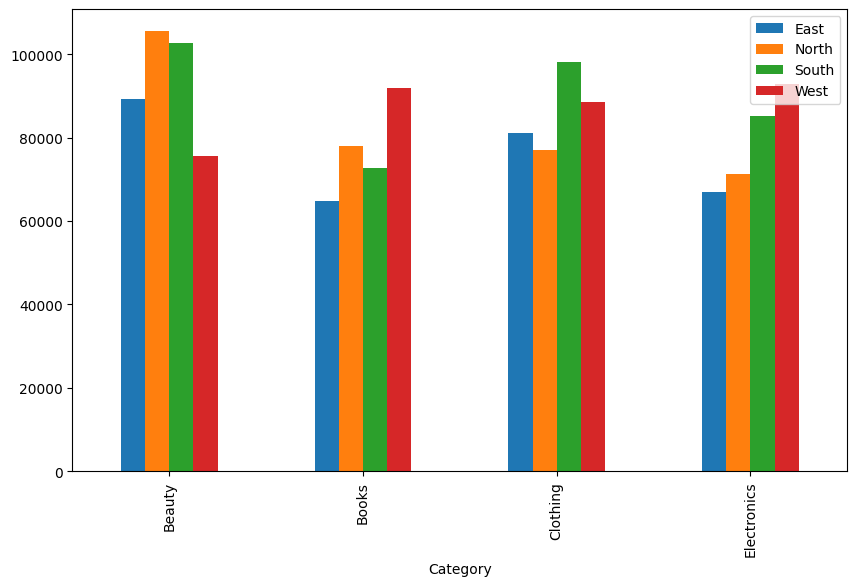

In [16]:
diagram = pivot_tab.iloc[:, :].plot(kind='bar', figsize=(10, 6))
diagram.legend(loc='upper right')

## 11. Exporting insights
In real-world project, you wouldn't just show code; you would provide with a clean file to open in Excel or a presentation.

In [17]:
df.to_csv('ecommerce_analysis_report.csv', index=False)

In [18]:
# store the top 10 list in a file according to performance score
top10 = df.sort_values(by='Performance_Score', ascending=False).head(10)
top10.to_csv('top10.csv', index=False)